### DATOS DEL SENSOR EN EL MOTOR DE 2025

Queremos analizar los datos recogidos con nuestro sensor del combustible del motor. Los datos que tenemos son el voltaje y el tiempo. Para ello haremos primero un eda y después pasaremos a procesar la señal y sacar las gráficas que nos interesan.

In [2]:
#Primero importamos las librerias
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
from scipy import signal
import pywt

%matplotlib inline

#Leemos los datos
df = pd.read_csv("Measurement_17_15.asc", sep=r"\s+", skiprows=2)
df

,Begin,Triggerblock,Fri,May,15,07:26:14,pm,2026
0,0.170000,SV:,1,0,0.0,::sysAnalog_01,=,0.000
1,0.170000,SV:,1,0,0.0,::sysAnalog_02,=,0.000
2,0.170000,SV:,1,0,0.0,::sysAnalog_03,=,0.000
3,0.172000,SV:,1,0,0.0,::sysAnalog_03,=,0.659
4,0.174000,SV:,1,0,0.0,::sysAnalog_03,=,0.641
...,...,...,...,...,...,...,...,...
42578,60.994000,SV:,1,0,0.0,::sysAnalog_03,=,0.712
42579,60.996000,SV:,1,0,0.0,::sysAnalog_03,=,0.605
42580,60.998000,SV:,1,0,0.0,::sysAnalog_03,=,0.356
42581,60.999000,log,trigger,event,NaN,NaN,NaN,NaN


Vemos que los datos, al no tener encabezado per se, nos interesan sólo las columnas Begin y 2026 que serían el tiempo y el voltaje así que vamos a eliminar el resto de columnas y renombrarlas.

In [3]:
#Primero borramos el resto de columnas
df_motor=df.drop(columns=["Triggerblock", "Fri", "May", "15", "pm"])
df_motor

,Begin,07:26:14,2026
0,0.170000,::sysAnalog_01,0.000
1,0.170000,::sysAnalog_02,0.000
2,0.170000,::sysAnalog_03,0.000
3,0.172000,::sysAnalog_03,0.659
4,0.174000,::sysAnalog_03,0.641
...,...,...,...
42578,60.994000,::sysAnalog_03,0.712
42579,60.996000,::sysAnalog_03,0.605
42580,60.998000,::sysAnalog_03,0.356
42581,60.999000,NaN,NaN


In [4]:
#Renombramos las columnas
df_motor=df_motor.rename(columns={
    'Begin':'tiempo',
    '07:26:14':'sensor',
    '2026':'voltaje'
})
df_motor

,tiempo,sensor,voltaje
0,0.170000,::sysAnalog_01,0.000
1,0.170000,::sysAnalog_02,0.000
2,0.170000,::sysAnalog_03,0.000
3,0.172000,::sysAnalog_03,0.659
4,0.174000,::sysAnalog_03,0.641
...,...,...,...
42578,60.994000,::sysAnalog_03,0.712
42579,60.996000,::sysAnalog_03,0.605
42580,60.998000,::sysAnalog_03,0.356
42581,60.999000,NaN,NaN


In [ ]:
#Dividimos los sets, uno para cada sensor
df_sensor1=df_motor[df_motor['sensor']=='::sysAnalog_01'] #Temperatura (100Hz)
df_sensor2=df_motor[df_motor['sensor']=='::sysAnalog_02'] #Marchas(100Hz)
df_sensor3=df_motor[df_motor['sensor']=='::sysAnalog_03'] #Revoluciones (500Hz)

## Visualizar los set
Ahora que tenemos los set separados, podemos analizar los datos de cada uno. Primero los graficamos para ver que, obviamente, tenemos que tranformarlos

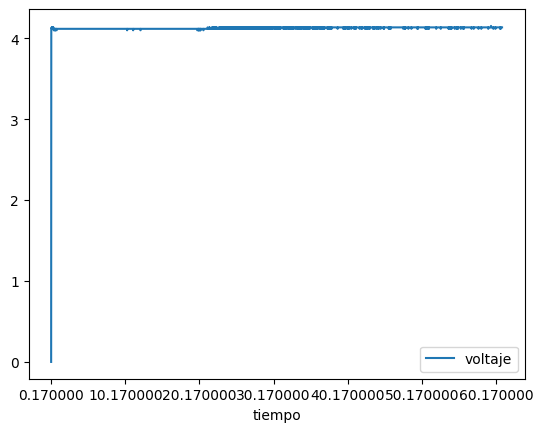

In [6]:
#Graficamos los datos del sensor 1
df_sensor1.plot(kind='line', x='tiempo', y='voltaje')
plt.show()

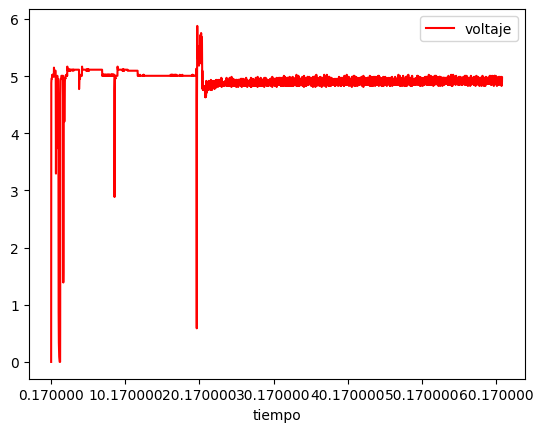

In [7]:
#Graficamos los datos del sensor 2
df_sensor2.plot(kind='line', x='tiempo', y='voltaje', style='red')
plt.show()

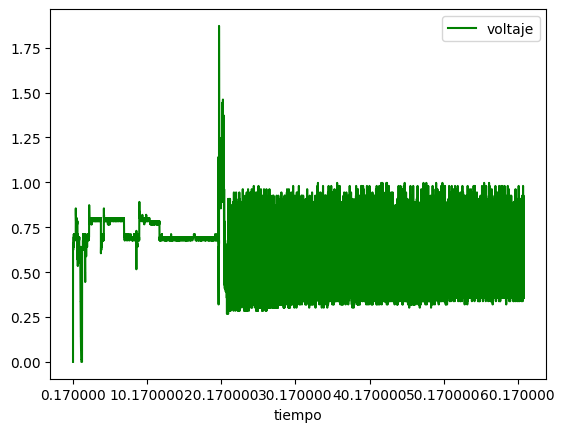

In [8]:
#Graficamos los datos del sensor 3
df_sensor3.plot(kind='line', x='tiempo', y='voltaje', style='green')
plt.show()

# Transformación de los datos - Sensor 1
Vamos a hacer la transformada de Fourier de los datos para poder tratarlos, en vez de en segundos(tiempo) en el régimen de frecuencias. Vamos a hacer un detrend en el voltaje por lo que pasamos las x e y a tipo numpy.

Text(0, 0.5, 'voltaje')

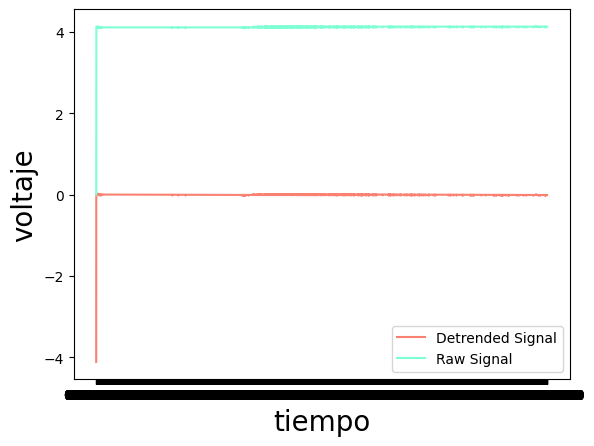

In [9]:
x1=np.array(df_sensor1.tiempo)
y1=np.array(df_sensor1.voltaje)

#Utilizamos detrend para corregir la tendencia y comparamos representandolas

y1_detrend = signal.detrend(y1)
plt.plot(x1, y1_detrend,color='salmon',label='Detrended Signal')
plt.plot(x1,y1, color='aquamarine',label='Raw Signal')
plt.legend()
plt.xlabel('tiempo',fontsize=20)
plt.ylabel('voltaje',fontsize=20)

(0.0, 200.0)

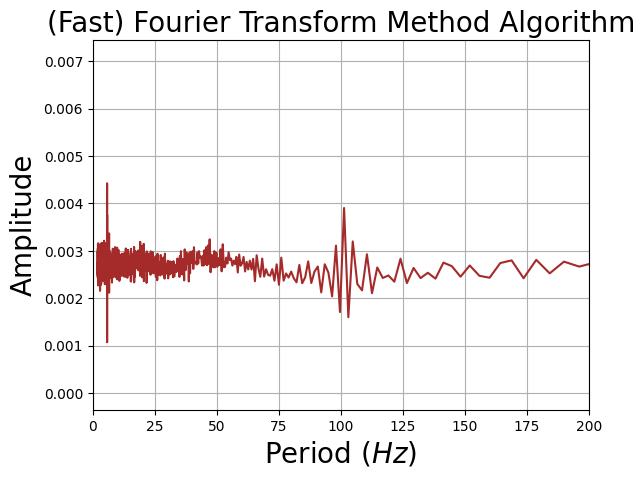

In [10]:
#Hacemos ahora un analisis de la frecuencia utilizando la transformada
# de Fourier con la funcion fft de numpy y conseguir la amplitud de la señal

FFT=np.fft.fft(y1_detrend)

new_N=int(len(FFT)/2)
f_nat=1

#linspace nos devuelve los numeros igual espaciados en el intervalo
new_X=np.linspace(10**-12, f_nat/2, new_N, endpoint=True)
new_Xph=1.0/(new_X)

FFT_abs=np.abs(FFT)

plt.plot(new_Xph,2*FFT_abs[0:int(len(FFT)/2.)]/len(new_Xph),color='brown')
plt.xlabel('Period ($Hz$)',fontsize=20)
plt.ylabel('Amplitude',fontsize=20)
plt.title('(Fast) Fourier Transform Method Algorithm',fontsize=20)
plt.grid(True)
plt.xlim(0,200)


In [11]:
#Sacamos los datos de los picos como indices(izquierda)

fft_abs = 2*FFT_abs[0:int(len(FFT)/2.)]/len(new_Xph)
fft_abs = pd.DataFrame(fft_abs, columns = ['Amplitude'])
fft_sorted = fft_abs.sort_values(by='Amplitude',ascending=False).head(20)
fft_sorted

,Amplitude
1,0.007095
3,0.006026
2,0.005487
1053,0.004426
60,0.003905
1051,0.003758
5,0.003663
6,0.003455
1058,0.003414
924,0.003368


In [12]:
#Podemos filtrar la señal y quedarnos con la banda de frecuencia que queramos
#Primero definimos la funcion de filtrado

def fft_filter(th):
    fft_tof=FFT.copy()
    fft_tof_abs=np.abs(fft_tof)
    fft_tof_abs=2*fft_tof_abs/len(new_Xph)
    fft_tof[fft_tof_abs<=th]=0
    return fft_tof

#Definimos la funcion de filtrado de la amplitud

def fft_filter_amp(th):
    fft_tof=FFT.copy()
    fft_tof_abs=np.abs(fft_tof)
    fft_tof_abs=2*fft_tof_abs/len(new_Xph)
    fft_tof_abs[fft_tof_abs<=th]=0
    return fft_tof_abs[0:int(len(fft_tof_abs)/2.)]

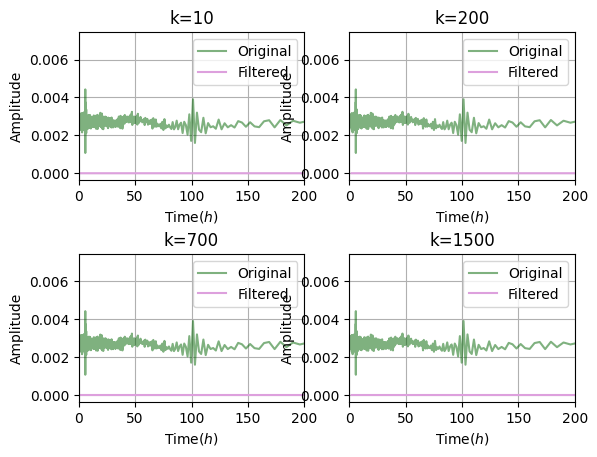

In [13]:
#Representamos los diferentes valores umbrales para el filtrado

K_plot=[10,200,700,1500]
j=0
for k in K_plot:
    j=j+1
    plt.subplot(2,2,j)
    plt.title('k=%i'%(k))
    plt.xlim(0,200)
    plt.plot(new_Xph,2*FFT_abs[0:int(len(FFT)/2.)]/len(new_Xph),
             color='darkgreen',alpha=0.5,label='Original')
    plt.grid(True)
    plt.plot(new_Xph,fft_filter_amp(k),'plum',label='Filtered')
    plt.xlabel('Time($h$)')
    plt.ylabel('Amplitude')
    plt.legend()
plt.subplots_adjust(hspace=0.5)

In [14]:
#Hacemos ahora el filtrado de los resultados

def fft_filter(perc):
    th=perc*(2*FFT_abs[0:int(len(FFT)/2.)]/len(new_Xph)).max()
    fft_tof=FFT.copy()
    fft_tof_abs=np.abs(fft_tof)
    fft_tof_abs=2*fft_tof_abs/len(new_Xph)
    fft_tof[fft_tof_abs<=th]=0
    return fft_tof

c:\Users\Inesita Bonita\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Inesita Bonita\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


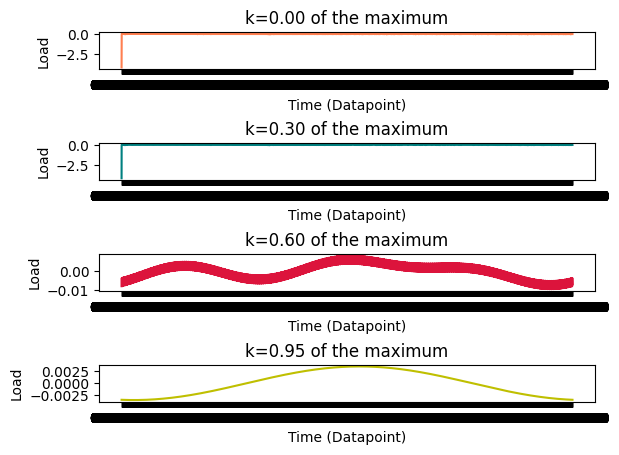

In [16]:
#Representamos para diferentes valores umbrales

#definimos los colores
colormap = np.array(['olive', 'coral', 'teal', 'crimson', 'y'])

K_plot_values=[0.0,0.30,0.60,0.95]
j=0
for k in K_plot_values:
    j+=1
    plt.subplot(4,1,j)
    plt.plot(x1,np.fft.ifft(fft_filter(k)),color=colormap[j])
    plt.title('k=%.2f of the maximum' %(k))
    plt.xlabel('Time (Datapoint)')
    plt.ylabel('Load')
plt.subplots_adjust(hspace=2)

# Transformación de los datos - Sensor 2

Text(0, 0.5, 'voltaje')

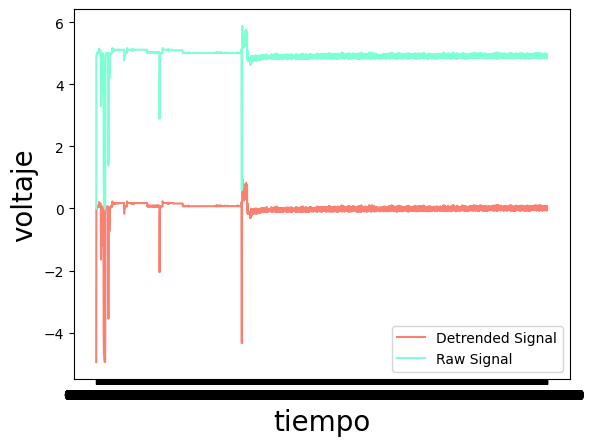

In [17]:
x2=np.array(df_sensor2.tiempo)
y2=np.array(df_sensor2.voltaje)

#Utilizamos detrend para corregir la tendencia y comparamos representandolas

y2_detrend = signal.detrend(y2)
plt.plot(x2, y2_detrend,color='salmon',label='Detrended Signal')
plt.plot(x2,y2, color='aquamarine',label='Raw Signal')
plt.legend()
plt.xlabel('tiempo',fontsize=20)
plt.ylabel('voltaje',fontsize=20)

# Transformación de los datos - Sensor 3

Text(0, 0.5, 'voltaje')

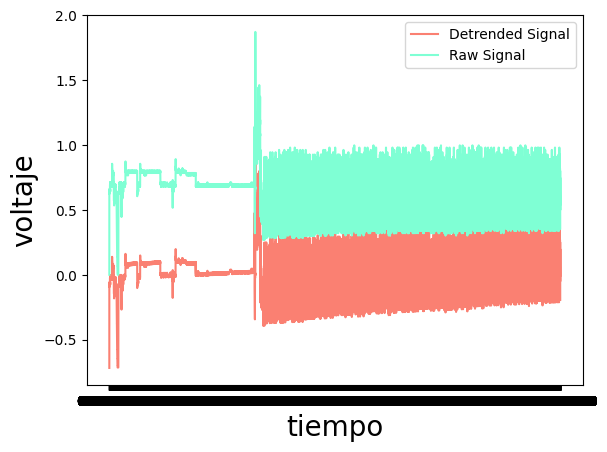

In [18]:
x3=np.array(df_sensor3.tiempo)
y3=np.array(df_sensor3.voltaje)

#Utilizamos detrend para corregir la tendencia y comparamos representandolas

y3_detrend = signal.detrend(y3)
plt.plot(x3, y3_detrend,color='salmon',label='Detrended Signal')
plt.plot(x3,y3, color='aquamarine',label='Raw Signal')
plt.legend()
plt.xlabel('tiempo',fontsize=20)
plt.ylabel('voltaje',fontsize=20)